___
# <font color= #003366> **Primer Examen Parcial** </font>
- <Strong> Integrantes: </Strong>  <font color="blue">`Clara Paola Aguilar Casillas, Roi Jared Flores Garza Stone, Mónica Ibarra Herrera, Diana Denise Valdivia Vargas` </font>
- <Strong> Materia: </Strong>  <font color="blue">`Modelos No Lineales Para Pronósticos` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

## <font color= #003366> **Objetivo** </font>

El objetivo del examen es desarrollar un modelo SARIMAX usando información obtenida mediante la API del Banco de México, con el fin de analizar y predecir el comportamiento del tipo de cambio de peso mexicano frente al dólar estadounidense.

Se busca identificar la estructura de la serie, evaluar su estacionariedad, estimar los parámetros óptimos del modelo y generar pronósticos diarios para el periodo del 5 al 13 de marzo de 2026.

Finalmente, se evaluará qué tan bien el puede capturar el modelo la dinámica del tipo de cambio.

## <font color= #003366> **Descripción de la Serie de Tiempo** </font>

La serie de tiempo que se usará en el examen corresponde al Tipo de Cambio FIX (peso mexicano – dólar estadounidense) publicado por el Banco de México.

Las características principales de la serie son:
- Nombre: Tipo de cambio FIX (MXN/USD)
- Fuente: API del Banco de México (SIE)
- Clave de serie: SF43718
- Frecuencia: Diaria
- Descripción: Indicador financiero publicado por Banxico que refleja el tipo de cambio peso mexicano - dólar estadounidense

## <font color= #003366> **Librerías** </font>

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import adfuller, acf, pacf, kpss
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import plotly.graph_objects as go
import plotly.io as pio
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
pio.renderers.default = "vscode"

## <font color= #003366> **Conectar con la API** </font>

In [2]:
token = "c08c91a75598ee1e94c2081fb597314804b58642f10913c1e53f81c258ba5f17"

# Serie FIX
serie = "SF63528"

url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie}/datos"

headers = {
    "Bmx-Token": token
}

response = requests.get(url, headers=headers)

data = response.json()

In [3]:
datos = data['bmx']['series'][0]['datos']

df = pd.DataFrame(datos)

df.columns = ['fecha', 'tipo_cambio']

df['fecha'] = pd.to_datetime(df['fecha'], format='%d/%m/%Y')

df['tipo_cambio'] = pd.to_numeric(df['tipo_cambio'], errors='coerce')

df = df.sort_values('fecha')

df.set_index('fecha', inplace=True)
df = df.asfreq('B')
df['tipo_cambio'] = df['tipo_cambio'].ffill()
df.head()

,tipo_cambio
fecha,
1954-04-19,0.0125
1954-04-20,0.0125
1954-04-21,0.0125
1954-04-22,0.0125
1954-04-23,0.0125


In [4]:
df_complete = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
missing_dates = df_complete.difference(df.index)

print("Número de fechas faltantes:", len(missing_dates))
missing_dates[:10]

Número de fechas faltantes: 7500


DatetimeIndex(['1954-04-24', '1954-04-25', '1954-05-01', '1954-05-02',
               '1954-05-08', '1954-05-09', '1954-05-15', '1954-05-16',
               '1954-05-22', '1954-05-23'],
              dtype='datetime64[us]', freq=None)

In [5]:
df_daily = df.reindex(df_complete)
df_daily.index.name = "fecha"

df_daily.head(10)

,tipo_cambio
fecha,
1954-04-19,0.0125
1954-04-20,0.0125
1954-04-21,0.0125
1954-04-22,0.0125
1954-04-23,0.0125
1954-04-24,NaN
1954-04-25,NaN
1954-04-26,0.0125
1954-04-27,0.0125


In [6]:
df_daily['tipo_cambio'] = df_daily['tipo_cambio'].ffill()
df_daily.head(10)

,tipo_cambio
fecha,
1954-04-19,0.0125
1954-04-20,0.0125
1954-04-21,0.0125
1954-04-22,0.0125
1954-04-23,0.0125
1954-04-24,0.0125
1954-04-25,0.0125
1954-04-26,0.0125
1954-04-27,0.0125


## <font color= #003366> **Visualización de la serie de tiempo** </font>

In [8]:
df = df_daily[df_daily.index >= "2021-01-01"]

df_plot = df.reset_index()

fig = px.line(
    df_plot,
    x="fecha",
    y="tipo_cambio",
    title="Tipo de Cambio FIX MXN/USD (20 años)"
)

fig.show()

## <font color= #003366> &ensp; •  **Pruebas de Estacionareidad** </font>
Un supuesto que se tiene al trabajar con modelos **SARIMA** es la estacionariedad, la cuál es la propiedad que mantiene media, varianza y autocovarianza constantes a lo largo del tiempo.

Para validar si una serie de tiempo es estacionaria, se realizan las siguientes pruebas:
- Augmented Dickey-Fuller (ADF)

In [9]:
def check_stationarity(series, title="Serie Original"):
    result = adfuller(series.dropna())
    print(f'ADF Test: {title}')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    is_stationary = result[1] < 0.05
    print(f"¿Es estacionaria? {'SÍ' if is_stationary else 'NO'}\n")
    return is_stationary

# 1. Revisamos la serie original
check_stationarity(df['tipo_cambio'], "Tipo de Cambio Original")

# 2. Aplicamos Primera Diferencia (d=1)
df['diff_1'] = df['tipo_cambio'].diff()

# 3. Revisamos la serie diferenciada
check_stationarity(df['diff_1'], "Primera Diferencia (d=1)")

# Creamos una figura con 2 columnas (Subplots)
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Serie Original (No Estacionaria)", "Serie Diferenciada (Estacionaria d=1)")
)

# Gráfico 1: Serie Original
fig.add_trace(
    go.Scatter(x=df['tipo_cambio'].index, y=df['tipo_cambio'], name='Original'),
    row=1, col=1
)

# Gráfico 2: Serie Diferenciada
fig.add_trace(
    go.Scatter(x=df['diff_1'].index, y=df['diff_1'], name='Diferenciada'),
    row=1, col=2
)

# Ajustes de diseño
fig.update_layout(
    title_text="Comparativa: Efecto de la Diferenciación",
    showlegend=False, # Ocultamos leyenda
    height=500
)

fig.show()

ADF Test: Tipo de Cambio Original
Estadístico ADF: -1.2336
p-value: 0.6590
¿Es estacionaria? NO

ADF Test: Primera Diferencia (d=1)
Estadístico ADF: -13.5616
p-value: 0.0000
¿Es estacionaria? SÍ



Con la prueba de Estacionareidad podemos ver que la serie original **no** es estacionaria.

Se realizó la primera defirenciación y al volver a realizar la prueba podemos visualizar que la serie ya es estacionaria

## <font color= #003366> **Gráficas de ACF y PACF** </font>

In [10]:
ts_analysis = df['diff_1'].dropna()

# Parámetros
lags = 30  # 30 días
alpha = 0.05 # Nivel de significancia del 95%

# Cálculo de valores ACF y PACF
acf_vals = acf(ts_analysis, nlags=lags, alpha=alpha)[0][1:]
pacf_vals = pacf(ts_analysis, nlags=lags, alpha=alpha)[0][1:]

# Colocamos manualmente el intervalo de confianza para plotly
n = len(ts_analysis)
conf_interval = 1.96 / np.sqrt(n)


fig = make_subplots(rows=2, cols=1,
                    subplot_titles=("Función de Autocorrelación (ACF) - Determina MA(q)",
                                    "Autocorrelación Parcial (PACF) - Determina AR(p)"),
                    vertical_spacing=0.15)

# ACF

fig.add_trace(go.Bar(
    x=list(range(1, lags+1)), y=acf_vals,
    name='ACF', marker_color='rgb(31, 119, 180)', showlegend=False
), row=1, col=1)

# Intervalos de confianza (Sombreado)
fig.add_shape(type="rect",
    x0=0.5, y0=-conf_interval, x1=lags+0.5, y1=conf_interval,
    line=dict(color="rgba(0,0,0,0)"), fillcolor="rgba(0,0,0,0.1)",
    row=1, col=1
)
# Líneas límite
fig.add_hline(y=conf_interval, line_dash="dash", line_color="gray", row=1, col=1)
fig.add_hline(y=-conf_interval, line_dash="dash", line_color="gray", row=1, col=1)

# PACF

fig.add_trace(go.Bar(
    x=list(range(1, lags+1)), y=pacf_vals,
    name='PACF', marker_color='rgb(255, 127, 14)', showlegend=False
), row=2, col=1)

# Intervalos de confianza
fig.add_shape(type="rect",
    x0=0.5, y0=-conf_interval, x1=lags+0.5, y1=conf_interval,
    line=dict(color="rgba(0,0,0,0)"), fillcolor="rgba(0,0,0,0.1)",
    row=2, col=1
)
# Líneas límite
fig.add_hline(y=conf_interval, line_dash="dash", line_color="gray", row=2, col=1)
fig.add_hline(y=-conf_interval, line_dash="dash", line_color="gray", row=2, col=1)


fig.update_layout(
    title='<b>Diagnóstico de Estructura: ACF y PACF</b><br><sup>Serie Diferenciada</sup>',
    template='plotly_white',
    height=700,
    bargap=0.8 # Barras delgadas estilo lollipop
)

fig.show()

In [12]:
df['diff_7'] = df['tipo_cambio'].diff(7).dropna()
ts_analysis = df['diff_7'].dropna()

# Parámetros
lags = 30  # 30 días
alpha = 0.05 # Nivel de significancia del 95%

# Cálculo de valores ACF y PACF
acf_vals = acf(ts_analysis, nlags=lags, alpha=alpha)[0][1:]
pacf_vals = pacf(ts_analysis, nlags=lags, alpha=alpha)[0][1:]

# Colocamos manualmente el intervalo de confianza para plotly
n = len(ts_analysis)
conf_interval = 1.96 / np.sqrt(n)


fig = make_subplots(rows=2, cols=1,
                    subplot_titles=("Función de Autocorrelación (ACF) - Determina MA(q)",
                                    "Autocorrelación Parcial (PACF) - Determina AR(p)"),
                    vertical_spacing=0.15)

# ACF

fig.add_trace(go.Bar(
    x=list(range(1, lags+1)), y=acf_vals,
    name='ACF', marker_color='rgb(31, 119, 180)', showlegend=False
), row=1, col=1)

# Intervalos de confianza (Sombreado)
fig.add_shape(type="rect",
    x0=0.5, y0=-conf_interval, x1=lags+0.5, y1=conf_interval,
    line=dict(color="rgba(0,0,0,0)"), fillcolor="rgba(0,0,0,0.1)",
    row=1, col=1
)
# Líneas límite
fig.add_hline(y=conf_interval, line_dash="dash", line_color="gray", row=1, col=1)
fig.add_hline(y=-conf_interval, line_dash="dash", line_color="gray", row=1, col=1)

# PACF

fig.add_trace(go.Bar(
    x=list(range(1, lags+1)), y=pacf_vals,
    name='PACF', marker_color='rgb(255, 127, 14)', showlegend=False
), row=2, col=1)

# Intervalos de confianza
fig.add_shape(type="rect",
    x0=0.5, y0=-conf_interval, x1=lags+0.5, y1=conf_interval,
    line=dict(color="rgba(0,0,0,0)"), fillcolor="rgba(0,0,0,0.1)",
    row=2, col=1
)
# Líneas límite
fig.add_hline(y=conf_interval, line_dash="dash", line_color="gray", row=2, col=1)
fig.add_hline(y=-conf_interval, line_dash="dash", line_color="gray", row=2, col=1)


fig.update_layout(
    title='<b>Diagnóstico de Estructura: ACF y PACF</b><br><sup>Serie Diferenciada</sup>',
    template='plotly_white',
    height=700,
    bargap=0.8 # Barras delgadas estilo lollipop
)

# Resaltar lags estacionales (7, 14, 21, 28, 35) con líneas verticales rojas tenues
for i in [7, 14, 21, 28, 35]:
    fig.add_vline(x=i, line_width=1, line_dash="dot", line_color="red", opacity=0.5)

fig.show()

## <font color= #66b0b0> &ensp; • **SARIMA** </font>

In [13]:
# Realizar train/test split de 10%
num_dias = 15

train = df.iloc[:-num_dias]
test = df.iloc[-num_dias:]

col_target = "tipo_cambio"

# Realizar modelo de SARIMA
model = SARIMAX(train[col_target],
                order=(1,1,1),
                seasonal_order=(1,0,2,7),
                trend='c')

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test))
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train[-num_dias-20:][col_target].index, y=train[-num_dias-20:][col_target],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test[col_target].index, y=test[col_target],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMA',
    line=dict(color='#606E34', width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMA: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()


--- Errores del modelo ---
RMSE: 0.06
MAPE: 0.24%
MAE: 0.04
                                       SARIMAX Results                                        
Dep. Variable:                            tipo_cambio   No. Observations:                 1872
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood                1522.563
Date:                                Mon, 02 Mar 2026   AIC                          -3031.126
Time:                                        21:24:25   BIC                          -2992.386
Sample:                                    01-01-2021   HQIC                         -3016.853
                                         - 02-15-2026                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0003

In [14]:
# Realizar modelo de SARIMA
model = SARIMAX(train[col_target],
                order=(1,1,1),
                seasonal_order=(1,1,1,7),
                trend='c')

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test))
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train[-num_dias-20:][col_target].index, y=train[-num_dias-20:][col_target],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test[col_target].index, y=test[col_target],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMA',
    line=dict(color='#606E34', width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMA: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()

c:\Users\denis\anaconda3\envs\deep\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\denis\anaconda3\envs\deep\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.




--- Errores del modelo ---
RMSE: 0.07
MAPE: 0.30%
MAE: 0.05
                                     SARIMAX Results                                     
Dep. Variable:                       tipo_cambio   No. Observations:                 1872
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                1500.178
Date:                           Mon, 02 Mar 2026   AIC                          -2988.357
Time:                                   21:25:25   BIC                          -2955.174
Sample:                               01-01-2021   HQIC                         -2976.129
                                    - 02-15-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.379e-05   4.47e-05     -0.308      0.758      -

In [16]:
# Realizar modelo de SARIMA
model = SARIMAX(train[col_target],
                order=(1,1,1),
                seasonal_order=(2,0,1,7),
                trend='c')

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test))
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train[-num_dias-20:][col_target].index, y=train[-num_dias-20:][col_target],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test[col_target].index, y=test[col_target],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMA',
    line=dict(color='#606E34', width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMA: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()


--- Errores del modelo ---
RMSE: 0.06
MAPE: 0.24%
MAE: 0.04
                                     SARIMAX Results                                     
Dep. Variable:                       tipo_cambio   No. Observations:                 1872
Model:             SARIMAX(1, 1, 1)x(2, 0, 1, 7)   Log Likelihood                1522.604
Date:                           Mon, 02 Mar 2026   AIC                          -3031.207
Time:                                   21:27:02   BIC                          -2992.467
Sample:                               01-01-2021   HQIC                         -3016.935
                                    - 02-15-2026                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0002      0.002     -0.132      0.895      -

## <font color= #66b0b0> &ensp; • **SARIMAX** </font>

In [258]:
# Tasa objetivo de Mexico
serie = "SF61745"

url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie}/datos"

headers = {
    "Bmx-Token": token
}

response = requests.get(url, headers=headers)
data = response.json()

# Extraer datos
datos = data["bmx"]["series"][0]["datos"]

# Convertir a DataFrame
tasa_mx = pd.DataFrame(datos)
tasa_mx.columns = ["fecha", "tasa_mx"]

# Limpiar datos
tasa_mx["fecha"] = pd.to_datetime(tasa_mx["fecha"], format="%d/%m/%Y")
tasa_mx["tasa_mx"] = pd.to_numeric(tasa_mx["tasa_mx"], errors="coerce")

tasa_mx = tasa_mx.set_index("fecha").sort_index()

tasa_mx.head()

,tasa_mx
fecha,
2008-01-21,7.5
2008-01-22,7.5
2008-01-23,7.5
2008-01-24,7.5
2008-01-25,7.5


In [259]:
from fredapi import Fred

# Tasa objetivo de EU
API_KEY = '5971983c33e5c55ccba85f8742864ef5 '

# Consultar la serie desde fred
fred = Fred(api_key=API_KEY)

tasa_us = fred.get_series("FEDFUNDS")

# Hazerlo df 
tasa_us = tasa_us.to_frame(name="tasa_us")
tasa_us.index = pd.to_datetime(tasa_us.index)

tasa_us.head()

,tasa_us
1954-07-01,0.80
1954-08-01,1.22
1954-09-01,1.07
1954-10-01,0.85
1954-11-01,0.83


In [260]:
# Convertir a frecuencia business
tasa_mx = tasa_mx.asfreq("B").ffill()
tasa_us = tasa_us.asfreq("B").ffill()

# Unir con el fix
df = df.join(tasa_mx).join(tasa_us)

# Crear diferencial
df["diff_tasas"] = df["tasa_mx"] - df["tasa_us"]

df = df.dropna()
df

,tipo_cambio,diff_1,diff_5,tasa_mx,tasa_us,diff_tasas
fecha,,,,,,
2015-01-08,14.6274,-0.1662,-0.1140,3.0,0.11,2.89
2015-01-09,14.5804,-0.0470,-0.2486,3.0,0.11,2.89
2015-01-12,14.6398,0.0594,-0.3071,3.0,0.11,2.89
2015-01-13,14.5559,-0.0839,-0.2920,3.0,0.11,2.89
2015-01-14,14.5644,0.0085,-0.2292,3.0,0.11,2.89
...,...,...,...,...,...,...
2025-12-26,17.9042,-0.0206,-0.1023,7.0,3.72,3.28
2025-12-29,17.9667,0.0625,-0.0118,7.0,3.72,3.28
2025-12-30,17.9528,-0.0139,0.0196,7.0,3.72,3.28


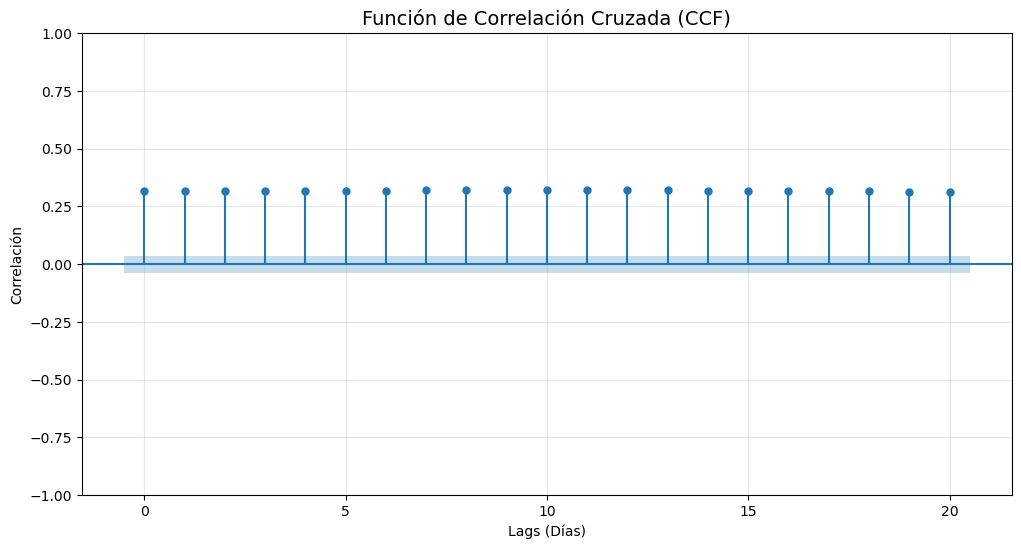

In [261]:
from statsmodels.graphics.tsaplots import plot_ccf
ccf_data = df[['tipo_cambio', 'diff_tasas']].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

# Importante: Usamos las series limpias (sin NaNs)
# Ponemos diff_tasas primero para ver cómo afecta a los Pasajeros (tipo_cambio)
plot_ccf(ccf_data['diff_tasas'], ccf_data['tipo_cambio'], lags=20, ax=ax, alpha=0.05)

plt.title("Función de Correlación Cruzada (CCF)", fontsize=14)
plt.xlabel("Lags (Días)")
plt.ylabel("Correlación")
plt.grid(alpha=0.3)
plt.show()

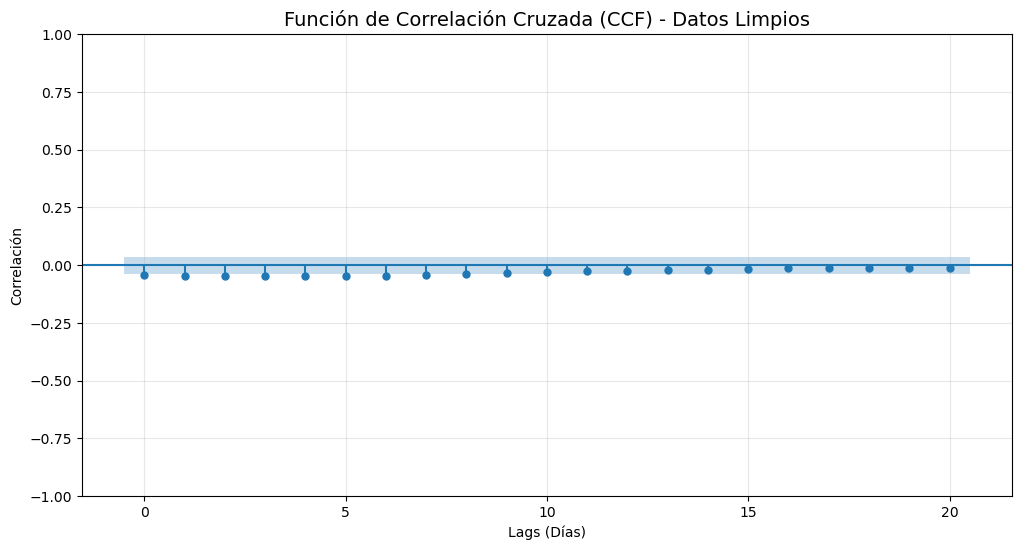

In [262]:
ccf_data = df[['diff_5', 'diff_tasas']].dropna()

fig, ax = plt.subplots(figsize=(12, 6))

plot_ccf(ccf_data['diff_tasas'], ccf_data['diff_5'], lags=20, ax=ax, alpha=0.05)

plt.title("Función de Correlación Cruzada (CCF) - Datos Limpios", fontsize=14)
plt.xlabel("Lags (Días)")
plt.ylabel("Correlación")
plt.grid(alpha=0.3)
plt.show()

In [263]:
from statsmodels.tsa.stattools import grangercausalitytests

print("\n" + "="*50)
print("PRUEBA DE CAUSALIDAD DE GRANGER")
print("Hipótesis Nula (H0): La diferencia de taza NO causan cambios en el fix.")
print("Serie analizada: tipo_cambio (Sin Diff Estacional)")
print("="*50)

# Preparamos el DataFrame para la prueba
# La primera columna debe ser la serie TARGET
# La segunda columna debe ser la serie AYUDA
granger_data = df[['tipo_cambio', 'diff_tasas']].dropna()

# Ejecutamos la prueba para los primeros 5 lags (días)
# verbose=True imprime los resultados detallados

granger_results = grangercausalitytests(granger_data, maxlag=7, verbose=True)


print("\n" + "="*50)
print("GUÍA DE INTERPRETACIÓN:")
print("Busca la fila 'ssr_ftest' y su columna 'p-value'.")
print("Si p < 0.05, estadísticamente la variable 'diff_tasas' ayuda a predecir 'tipo_cambio'.")
print("="*50)


PRUEBA DE CAUSALIDAD DE GRANGER
Hipótesis Nula (H0): La diferencia de taza NO causan cambios en el fix.
Serie analizada: tipo_cambio (Sin Diff Estacional)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0005  , p=0.9827  , df_denom=2862, df_num=1
ssr based chi2 test:   chi2=0.0005  , p=0.9827  , df=1
likelihood ratio test: chi2=0.0005  , p=0.9827  , df=1
parameter F test:         F=0.0005  , p=0.9827  , df_denom=2862, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.0944  , p=0.0168  , df_denom=2859, df_num=2
ssr based chi2 test:   chi2=8.2031  , p=0.0165  , df=2
likelihood ratio test: chi2=8.1913  , p=0.0166  , df=2
parameter F test:         F=4.0944  , p=0.0168  , df_denom=2859, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.8021  , p=0.0098  , df_denom=2856, df_num=3
ssr based chi2 test:   chi2=11.4342 , p=0.0096  , df=3
likelihood ratio test: chi2=11.4114 , p=0.0097  , df=3
parame

c:\Users\denis\anaconda3\envs\fashion-ae\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results



In [264]:
print("\n" + "="*50)
print("PRUEBA DE CAUSALIDAD DE GRANGER")
print("Hipótesis Nula (H0): La diferencia de taza NO causan cambios en el fix.")
print("Serie analizada: diff_5 (con Diff Estacional)")
print("="*50)

# Preparamos el DataFrame para la prueba
# La primera columna debe ser la serie TARGET
# La segunda columna debe ser la serie AYUDA
granger_data = df[['diff_5', 'diff_tasas']].dropna()

# Ejecutamos la prueba para los primeros 5 lags (días)
# verbose=True imprime los resultados detallados

granger_results = grangercausalitytests(granger_data, maxlag=7, verbose=True)


print("\n" + "="*50)
print("GUÍA DE INTERPRETACIÓN:")
print("Busca la fila 'ssr_ftest' y su columna 'p-value'.")
print("Si p < 0.05, estadísticamente la variable 'diff_tasas' ayuda a predecir 'diff_5'.")
print("="*50)


PRUEBA DE CAUSALIDAD DE GRANGER
Hipótesis Nula (H0): La diferencia de taza NO causan cambios en el fix.
Serie analizada: diff_5 (con Diff Estacional)

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.2854  , p=0.5932  , df_denom=2862, df_num=1
ssr based chi2 test:   chi2=0.2857  , p=0.5930  , df=1
likelihood ratio test: chi2=0.2857  , p=0.5930  , df=1
parameter F test:         F=0.2854  , p=0.5932  , df_denom=2862, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.4566  , p=0.2332  , df_denom=2859, df_num=2
ssr based chi2 test:   chi2=2.9183  , p=0.2324  , df=2
likelihood ratio test: chi2=2.9168  , p=0.2326  , df=2
parameter F test:         F=1.4566  , p=0.2332  , df_denom=2859, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9848  , p=0.3989  , df_denom=2856, df_num=3
ssr based chi2 test:   chi2=2.9615  , p=0.3976  , df=3
likelihood ratio test: chi2=2.9600  , p=0.3978  , df=3
parameter F

In [265]:
train = df.iloc[:-num_dias]
test = df.iloc[-num_dias:]

col_exog = ["diff_tasas"]

# Realizar modelo de SARIMAX
model = SARIMAX(
    train[col_target],
    exog=train[col_exog],
    order=(1,1,1),
    seasonal_order=(1,1,1,5),
    trend="c"
)

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test), exog=test[col_exog])
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train["tipo_cambio"][-num_dias-20:].index, y=train["tipo_cambio"][-num_dias-20:],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test["tipo_cambio"].index, y=test["tipo_cambio"],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMAX',
    line=dict(color="#606E34", width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMAX: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()


--- Errores del modelo ---
RMSE: 0.05
MAPE: 0.23%
MAE: 0.04
                                     SARIMAX Results                                     
Dep. Variable:                       tipo_cambio   No. Observations:                 2851
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                1367.964
Date:                           Sun, 01 Mar 2026   AIC                          -2721.927
Time:                                   14:45:26   BIC                          -2680.254
Sample:                               01-08-2015   HQIC                         -2706.897
                                    - 12-11-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   -2.72e-05   2.73e-05     -0.998      0.318   -8.0

In [266]:
# Realizar modelo de SARIMAX
model = SARIMAX(
    train[col_target],
    exog=train[col_exog],
    order=(1,1,1),
    seasonal_order=(1,0,2,5),
    trend="c"
)

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test), exog=test[col_exog])
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train["tipo_cambio"][-num_dias-20:].index, y=train["tipo_cambio"][-num_dias-20:],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test["tipo_cambio"].index, y=test["tipo_cambio"],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMAX',
    line=dict(color="#606E34", width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMAX: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()


--- Errores del modelo ---
RMSE: 0.09
MAPE: 0.45%
MAE: 0.08
                                       SARIMAX Results                                        
Dep. Variable:                            tipo_cambio   No. Observations:                 2851
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 5)   Log Likelihood                1385.185
Date:                                Sun, 01 Mar 2026   AIC                          -2754.371
Time:                                        14:45:30   BIC                          -2706.730
Sample:                                    01-08-2015   HQIC                         -2737.190
                                         - 12-11-2025                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0018

In [267]:
# Realizar modelo de SARIMAX
model = SARIMAX(
    train[col_target],
    exog=train[col_exog],
    order=(1,1,1),
    seasonal_order=None,
    trend="c"
)

results = model.fit(disp=False,method='powell')

# Predecimos n pasos hacia el futuro (donde n = tamaño del test)
forecast_object = results.get_forecast(steps=len(test), exog=test[col_exog])
forecast_vals = forecast_object.predicted_mean
conf_int = forecast_object.conf_int(alpha=0.05) # Intervalo del 95%

# Metricas de error
rmse = np.sqrt(mean_squared_error(test[col_target], forecast_vals))
mape = mean_absolute_percentage_error(test[col_target], forecast_vals)
mae = mean_absolute_error(test[col_target], forecast_vals)


print(f"\n--- Errores del modelo ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"MAE: {mae:.2f}")

print(results.summary())

# Grafica
fig = go.Figure()

# Train
fig.add_trace(go.Scatter(
    x=train["tipo_cambio"][-num_dias-20:].index, y=train["tipo_cambio"][-num_dias-20:],
    mode='lines',
    name='Train',
    line=dict(color='rgba(100, 100, 100, 0.6)', width=1.5)
))

# Test
fig.add_trace(go.Scatter(
    x=test["tipo_cambio"].index, y=test["tipo_cambio"],
    name='Test',
    line=dict(color='#1f77b4', width=3),
    marker=dict(size=6)
))

# Forecast
fig.add_trace(go.Scatter(
    x=test.index, y=forecast_vals,
    name='SARIMAX',
    line=dict(color="#606E34", width=3, dash='dot')
))

# Intervalos de Confianza
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 0],
    mode='lines', line=dict(width=0), showlegend=False, hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=conf_int.index, y=conf_int.iloc[:, 1],
    mode='lines', line=dict(width=0), fill='tonexty',
    fillcolor='rgba(96, 110, 52, 0.2)',
    name='Int. Confianza 95%', hoverinfo='skip'
))

# Titulos
fig.update_layout(
    title=f'<b>Modelo SARIMAX: Pronóstico de Tipo de Cambio MLB</b><br><sup>',
    xaxis_title='Fecha',
    yaxis_title='Tipo de cambio',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0.8)'),
    hovermode="x unified"
)

fig.show()


--- Errores del modelo ---
RMSE: 0.08
MAPE: 0.41%
MAE: 0.07
                               SARIMAX Results                                
Dep. Variable:            tipo_cambio   No. Observations:                 2851
Model:               SARIMAX(1, 1, 1)   Log Likelihood                1383.042
Date:                Sun, 01 Mar 2026   AIC                          -2756.084
Time:                        14:45:31   BIC                          -2726.308
Sample:                    01-08-2015   HQIC                         -2745.345
                         - 12-11-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0017      0.004      0.390      0.697      -0.007       0.010
diff_tasas     0.0651      0.016      4.077      0.000       0.034    